In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [9]:
df_prod = pd.read_csv('Production_Total.csv')

In [10]:
df_prod['Country'] = df_prod['Country'].str.strip()
df_prod['Continent'] = df_prod['Continent'].str.strip()
)
years = [str(y) for y in range(1980, 2022)]

for col in years:
    df_prod[col] = df_prod[col].astype(str).str.strip().replace(['--', '-'], '0')
    df_prod[col] = pd.to_numeric(df_prod[col], errors='coerce').fillna(0)

In [11]:
df_prod

,Continent,Country,1980,1981,1982,1983,1984,1985,1986,1987,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Total_production
0,Africa,Algeria,2.803017,3.037537,3.224934,3.606400,3.859176,3.907466,3.968325,4.218086,...,6.510418,6.561750,6.696193,6.910710,6.830371,6.755066,6.474600,5.972770,6.656882,238.118858
1,Africa,Angola,0.335098,0.291294,0.276262,0.395408,0.462550,0.511269,0.621433,0.789429,...,3.932204,3.802528,3.949947,3.935297,3.899021,3.814151,3.526638,3.159337,2.824018,90.852722
2,Africa,Benin,0.000000,0.000000,0.000000,0.008960,0.015730,0.017930,0.017930,0.015690,...,0.000019,0.000019,0.000056,0.000092,0.000055,0.000046,0.000072,0.000062,0.000071,0.178363
3,Africa,Botswana,0.008262,0.008485,0.009242,0.008797,0.008752,0.009732,0.010912,0.010845,...,0.033335,0.038241,0.046562,0.041967,0.049654,0.048448,0.047232,0.041992,0.044393,0.952582
4,Africa,Burkina Faso,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001107,0.000961,0.000988,0.001431,0.001456,0.002067,0.001906,0.001860,0.002055,0.033589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,Central & South America,Trinidad and Tobago,0.550035,0.612443,0.502478,0.484613,0.575515,0.610607,0.528431,0.494887,...,1.783162,1.754012,1.642887,1.529336,1.412715,1.473662,1.481847,1.295506,1.107441,43.807634
225,Central & South America,Turks and Caicos Islands,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000009,0.000009,0.000009,0.000011,0.000037
226,Central & South America,U.S. Virgin Islands,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000012,0.000068,0.000124,0.000123,0.000067,0.000127,0.000125,0.000123,0.000150,0.005367
227,Central & South America,Uruguay,0.023363,0.026342,0.025309,0.074850,0.073425,0.066694,0.075389,0.074871,...,0.094341,0.118105,0.120003,0.124727,0.130897,0.130535,0.142058,0.111706,0.119688,3.261444


In [12]:
df_long = df_prod.melt(
    id_vars=['Continent', 'Country'], 
    value_vars=years, 
    var_name='Year', 
    value_name='Production'
)
df_long['Year'] = df_long['Year'].astype(int)

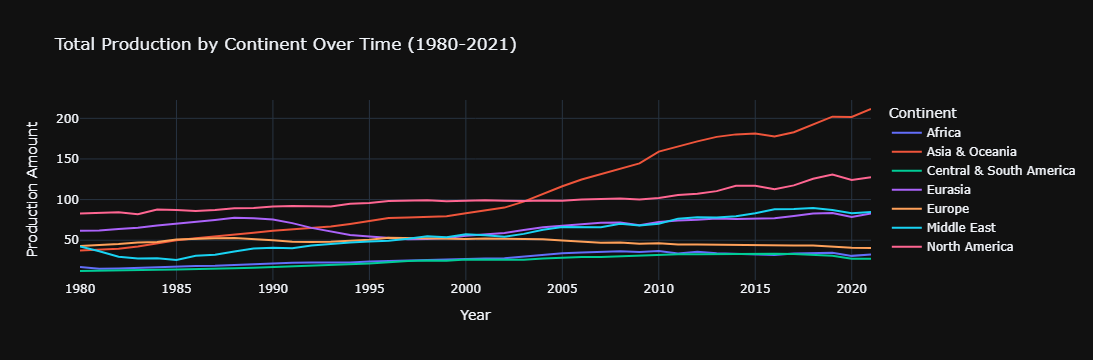

In [18]:
df_continent = df_long.groupby(['Continent', 'Year'])['Production'].sum().reset_index()

fig1 = px.line(
    df_continent, 
    x='Year', 
    y='Production', 
    color='Continent', 
    title='Total Production by Continent Over Time (1980-2021)',
    labels={'Production': 'Production Amount', 'Year': 'Year', 'Continent': 'Continent'},
    template='plotly_dark')
fig1.show()

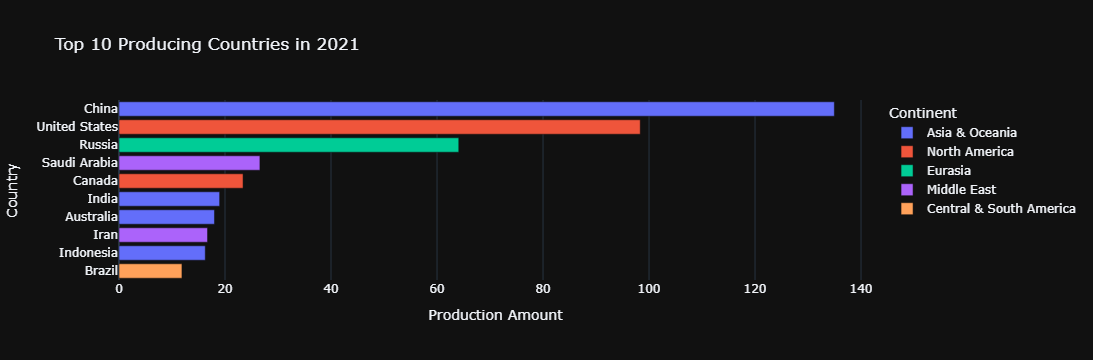

In [19]:
df_2021 = df_long[df_long['Year'] == 2021].nlargest(10, 'Production')

fig2 = px.bar(
    df_2021, 
    x='Production', 
    y='Country', 
    color='Continent', 
    orientation='h',
    title='Top 10 Producing Countries in 2021',
    labels={'Production': 'Production Amount', 'Country': 'Country', 'Continent': 'Continent'},
    template='plotly_dark' 
)
fig2.update_layout(yaxis={'categoryorder': 'total ascending'})
fig2.show()

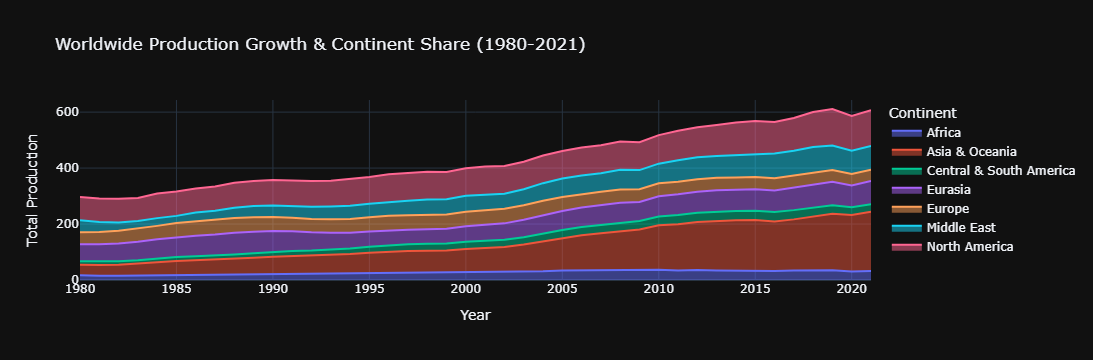

In [21]:
df_continent = df_long.groupby(['Continent', 'Year'])['Production'].sum().reset_index()

fig4 = px.area(
    df_continent, 
    x='Year', 
    y='Production', 
    color='Continent', 
    title='Worldwide Production Growth & Continent Share (1980-2021)',
    labels={'Production': 'Total Production', 'Year': 'Year', 'Continent': 'Continent'},
    template='plotly_dark'
)
fig4.show()

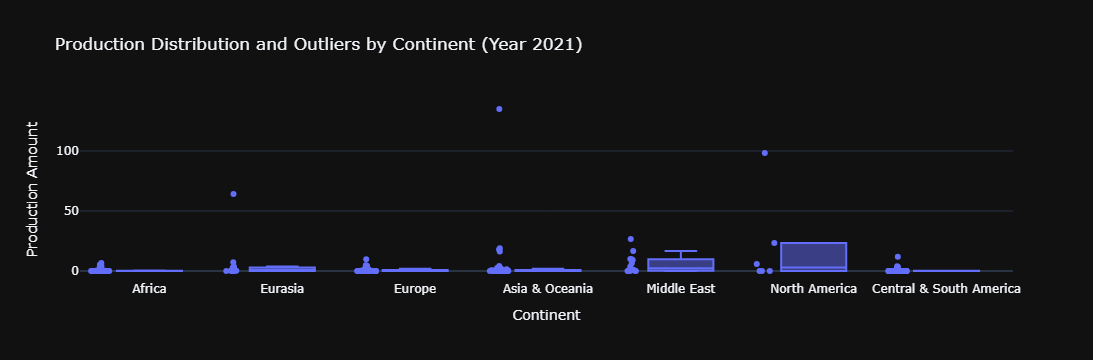

In [22]:
df_2021 = df_long[df_long['Year'] == 2021]

fig5 = px.box(
    df_2021,
    x='Continent',
    y='Production',
    points="all",  
    hover_data=['Country'],
    title='Production Distribution and Outliers by Continent (Year 2021)',
    labels={'Production': 'Production Amount', 'Continent': 'Continent'},
    template='plotly_dark'
)
fig5.show()

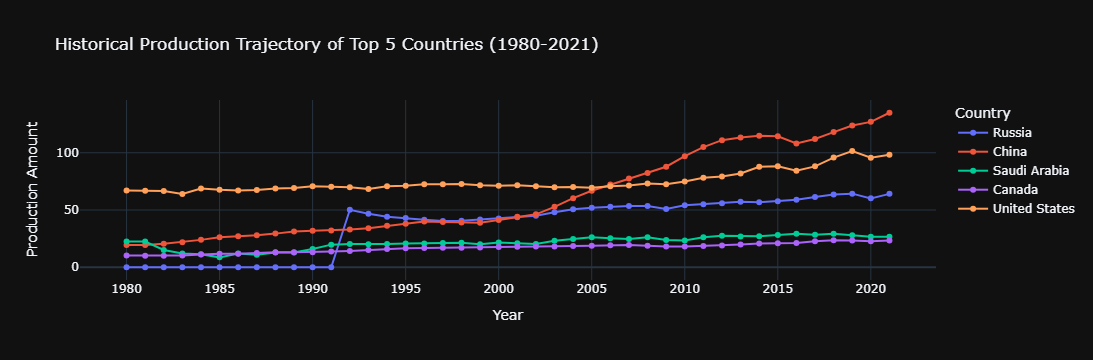

In [23]:
top_5_countries = df_long[df_long['Year'] == 2021].nlargest(5, 'Production')['Country'].tolist()

df_top5 = df_long[df_long['Country'].isin(top_5_countries)]

fig6 = px.line(
    df_top5,
    x='Year',
    y='Production',
    color='Country',
    markers=True, 
    title='Historical Production Trajectory of Top 5 Countries (1980-2021)',
    labels={'Production': 'Production Amount', 'Year': 'Year', 'Country': 'Country'},
    template='plotly_dark'
)
fig6.show()

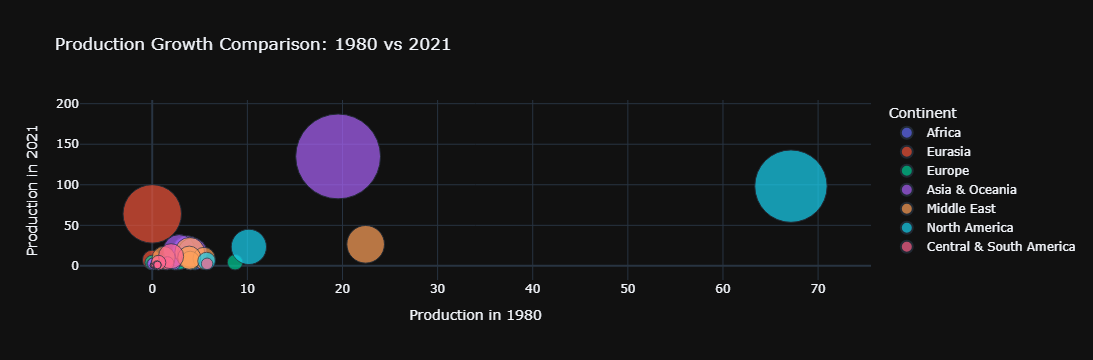

In [27]:
df_prod['Total_production'] = pd.to_numeric(df_prod['Total_production'], errors='coerce').fillna(0)
fig_scatter = px.scatter(
    df_prod,
    x='1980',
    y='2021',
    size='2021',                
    color='Continent',          
    hover_name='Country',       
    size_max=60,               
    title='Production Growth Comparison: 1980 vs 2021',
    labels={'1980': 'Production in 1980', '2021': 'Production in 2021'},
    template='plotly_dark'     
)

fig_scatter.show()